<h1 style="
    text-align: center;
    color:  #0072bc 
;
    font-family: Georgia;
    font-size: 36px;
    font-weight: bold;
">
   Top 1000 Companies Analysis (EDA - Visulization)

<p style="
    text-align: center;
    color: #FFFFFF;
    font-family: Arial;
    font-size: 16px;
"> 
    Source : Ambitionbox.com

</p>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
# upload dataset into DataFrame
df = pd.read_csv("ambitionbox_top_companies.csv")
df

,Unnamed: 0,name,rating,review,salary,job,highly_rated,sector,location
0,0,TCS,3.2,120000.0,1050000.0,4100.0,Promotions,IT Services & Consulting,Bengaluru
1,1,Accenture,3.7,79600.0,740000.0,14900.0,Promotions,IT Services & Consulting,Bengaluru
2,2,Wipro,3.6,69900.0,490000.0,6.0,Promotions,IT Services & Consulting,Hyderabad
3,3,Cognizant,3.7,66000.0,610000.0,782.0,Promotions,IT Services & Consulting,Hyderabad
4,4,Capgemini,3.6,58000.0,500000.0,2000.0,Work Life Balance,IT Services & Consulting,Bengaluru
...,...,...,...,...,...,...,...,...,...
990,995,Skipper,3.8,1200.0,3400.0,6.0,Promotions,Industrial Machinery,Kolkata
991,996,Thermo,3.8,1200.0,7100.0,160.0,Work Life Balance,Biotechnology,Bengaluru
992,997,Zudio,3.9,1200.0,2400.0,0.0,Job Security,Retail,New Delhi
993,998,Writer,3.2,1200.0,3800.0,3.0,Promotions,BPO,Mumbai


In [5]:
df.drop(columns = "Unnamed: 0", inplace = True)
df

,name,rating,review,salary,job,highly_rated,sector,location
0,TCS,3.2,120000.0,1050000.0,4100.0,Promotions,IT Services & Consulting,Bengaluru
1,Accenture,3.7,79600.0,740000.0,14900.0,Promotions,IT Services & Consulting,Bengaluru
2,Wipro,3.6,69900.0,490000.0,6.0,Promotions,IT Services & Consulting,Hyderabad
3,Cognizant,3.7,66000.0,610000.0,782.0,Promotions,IT Services & Consulting,Hyderabad
4,Capgemini,3.6,58000.0,500000.0,2000.0,Work Life Balance,IT Services & Consulting,Bengaluru
...,...,...,...,...,...,...,...,...
990,Skipper,3.8,1200.0,3400.0,6.0,Promotions,Industrial Machinery,Kolkata
991,Thermo,3.8,1200.0,7100.0,160.0,Work Life Balance,Biotechnology,Bengaluru
992,Zudio,3.9,1200.0,2400.0,0.0,Job Security,Retail,New Delhi
993,Writer,3.2,1200.0,3800.0,3.0,Promotions,BPO,Mumbai


----------------------------------------------------------------------------------------------------

# $Visulization$ -

## 1. Univariate Analysis -

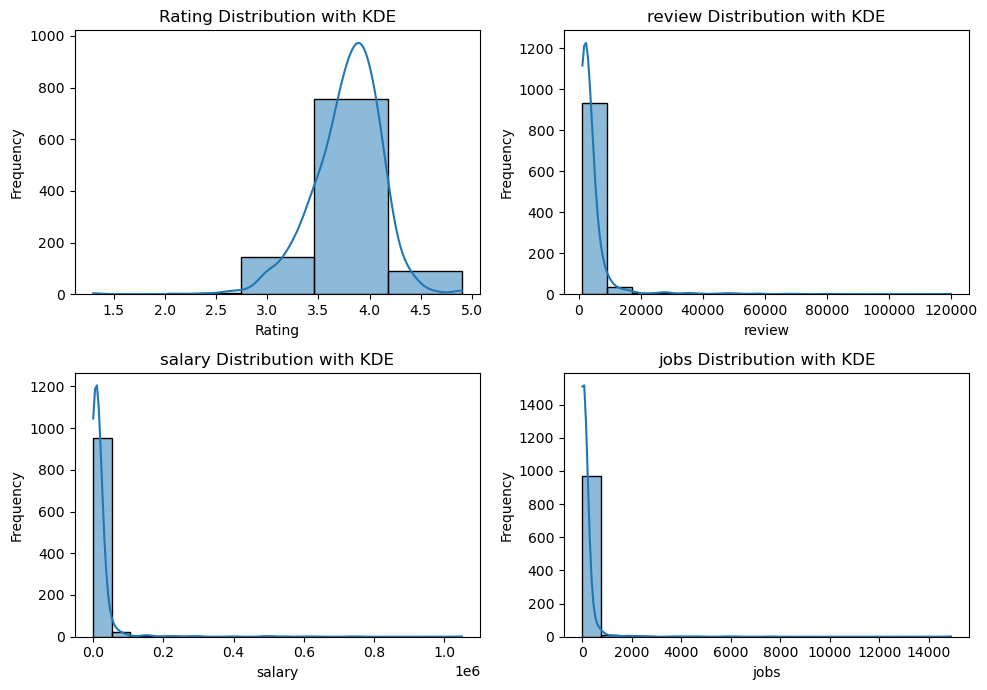

In [7]:
plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
sns.histplot(df["rating"],kde=True,bins=5)
plt.title("Rating Distribution with KDE")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.subplot(2,2,2)
sns.histplot(df["review"], kde=True , bins=15)
plt.title("review Distribution with KDE")
plt.xlabel("review")
plt.ylabel("Frequency")

plt.subplot(2,2,3)
sns.histplot(df["salary"], kde=True,bins=20)
plt.title("salary Distribution with KDE")
plt.xlabel("salary")
plt.ylabel("Frequency")

plt.subplot(2,2,4)
sns.histplot(df["job"], kde=True,bins=20)
plt.title("jobs Distribution with KDE")
plt.xlabel("jobs")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

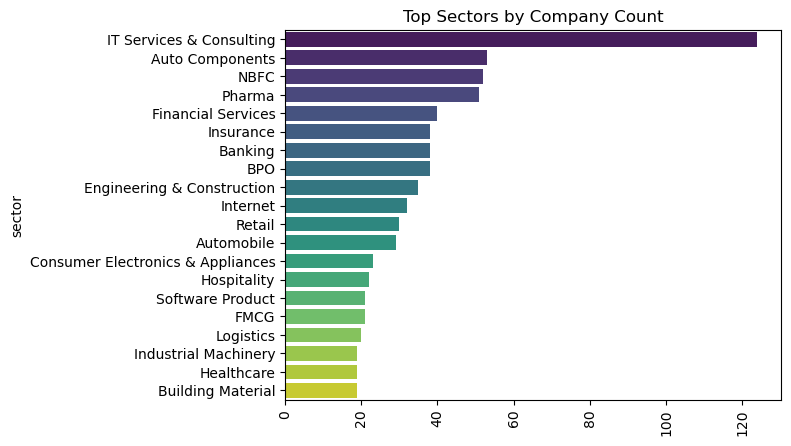

In [12]:

d=df["sector"].value_counts().head(20)
sns.barplot(x=d.values, y=d.index ,palette="viridis")
plt.title("Top Sectors by Company Count")
plt.xticks(rotation=90)
plt.show()

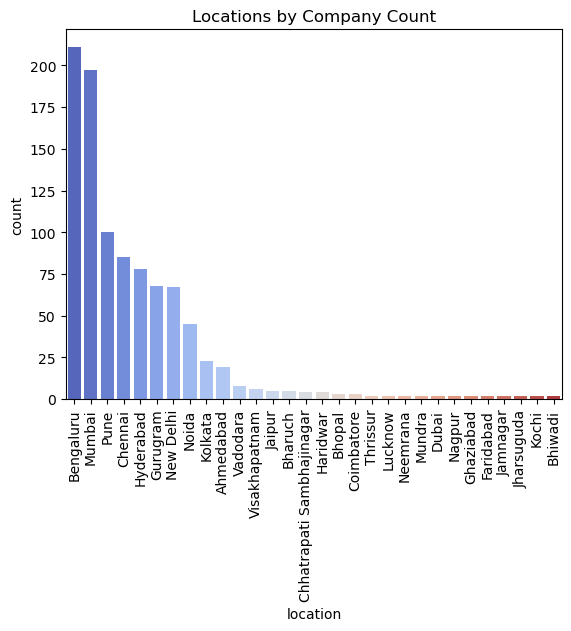

In [13]:
sns.barplot(df["location"].value_counts().head(30),palette="coolwarm")
plt.title("Locations by Company Count")
plt.xticks(rotation=90)
plt.show()

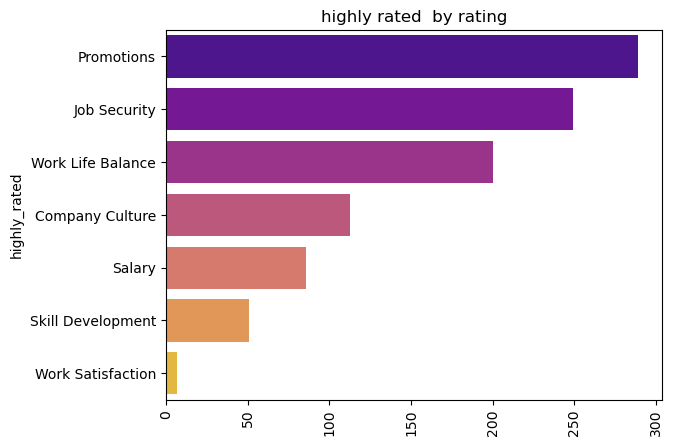

In [15]:
d=df["highly_rated"].value_counts()

sns.barplot(x=d.values, y=d.index,palette="plasma")
plt.title("highly rated  by rating")
plt.xticks(rotation=90)
plt.show()

## 2. Bivariate Analysis -

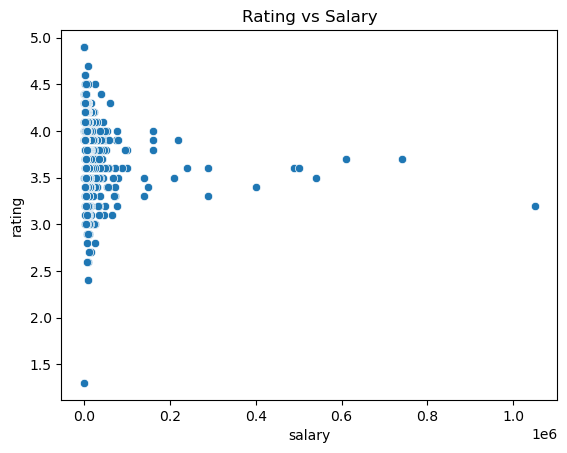

In [8]:
sns.scatterplot(x="salary", y="rating", data=df)
plt.title("Salary vs Rating")
plt.xlabel("salary")
plt.ylabel("rating")
plt.title("Rating vs Salary")
plt.show()

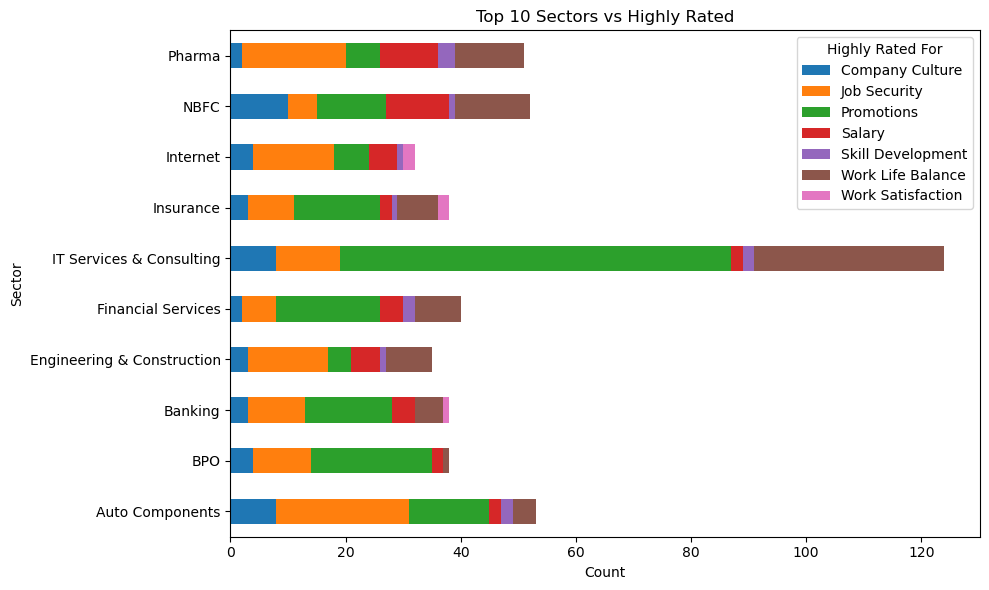

In [17]:
top10 = df["sector"].value_counts().head(10).index
filtered_df = df[df["sector"].isin(top10)]

ct = pd.crosstab(filtered_df["sector"], filtered_df["highly_rated"])

# Horizontal stacked chart (Sector on Y-axis)
ct.plot(kind="barh", stacked=True, figsize=(10,6))

plt.title("Top 10 Sectors vs Highly Rated")
plt.xlabel("Count")
plt.ylabel("Sector")   # Y-axis
plt.legend(title="Highly Rated For")
plt.tight_layout()
plt.show()

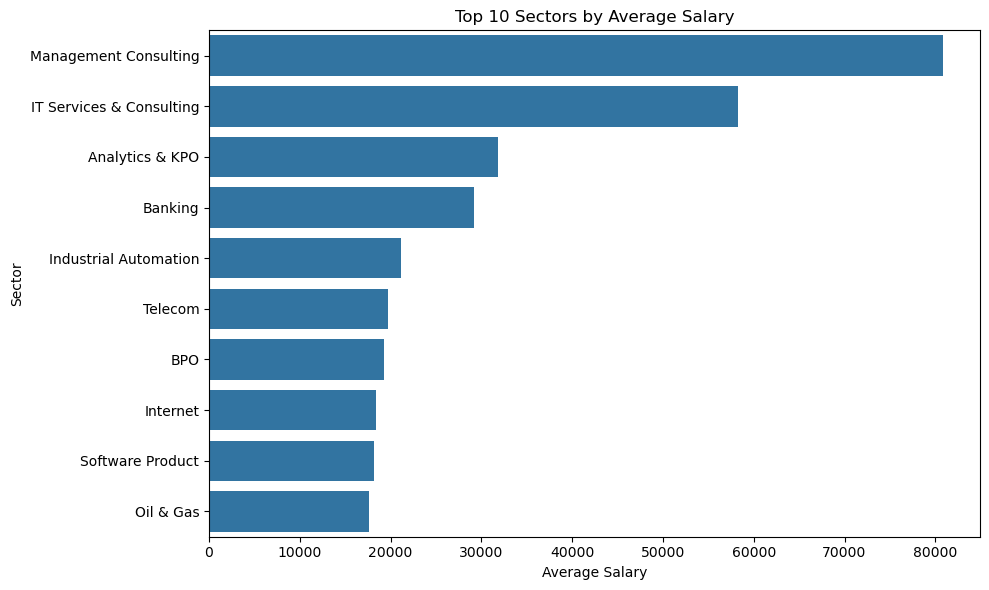

In [10]:
avg_salary = df.groupby("sector")["salary"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_salary.values, y=avg_salary.index)
plt.title("Top 10 Sectors by Average Salary")
plt.xlabel("Average Salary")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

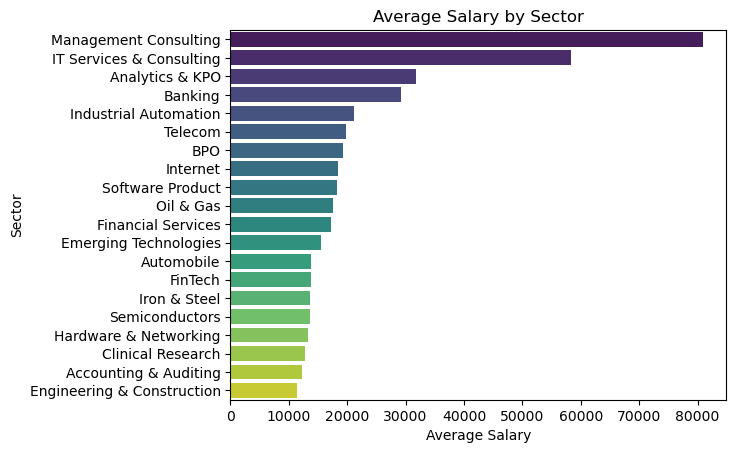

In [18]:
avg_salary = df.groupby("sector")["salary"].mean().sort_values(ascending=False).head(20)

sns.barplot(x=avg_salary.values, y=avg_salary.index,palette="viridis")

plt.title("Average Salary by Sector")
plt.xlabel("Average Salary")
plt.ylabel("Sector")
plt.show()

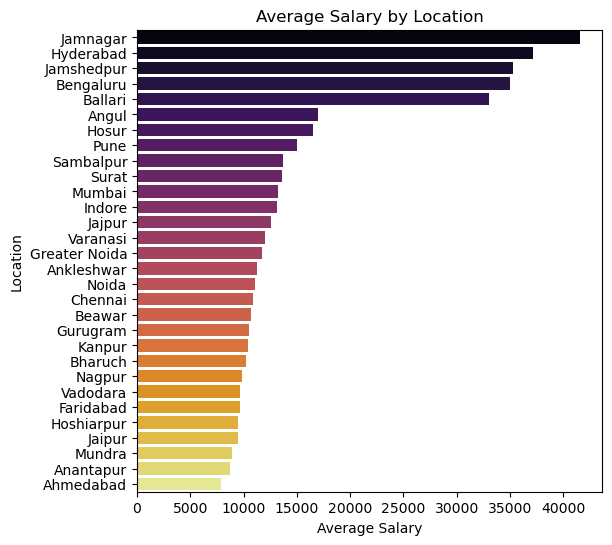

In [19]:
avg_salary_loc = df.groupby("location")["salary"].mean().sort_values(ascending=False).head(30)
plt.figure(figsize=(6,6))
sns.barplot(x=avg_salary_loc.values, y=avg_salary_loc.index,palette="inferno")
plt.title("Average Salary by Location")
plt.xlabel("Average Salary")
plt.ylabel("Location")
plt.show()

## 3. Multivariate Analysis -

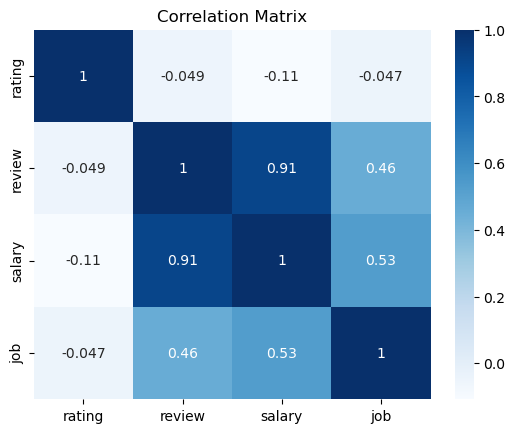

In [11]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap = "Blues")
plt.title("Correlation Matrix")
plt.show()

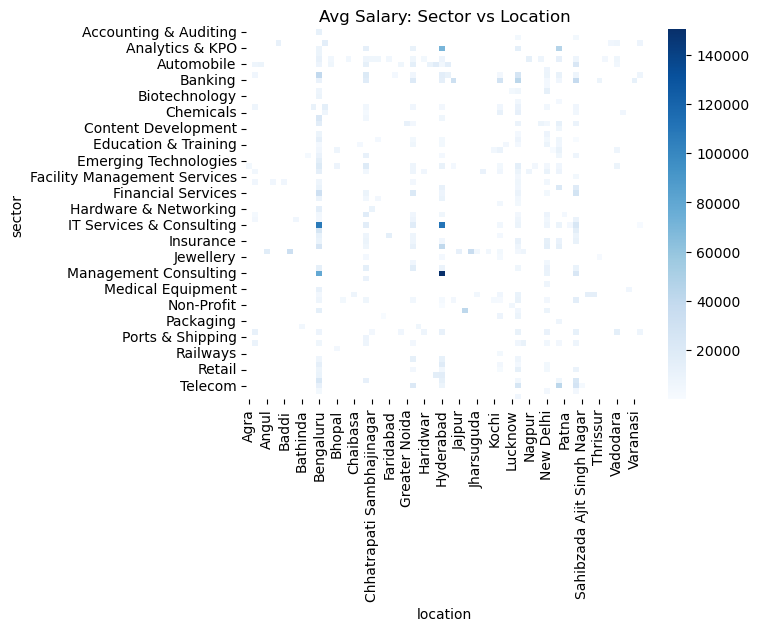

In [12]:
pivot = df.pivot_table(
    values="salary",
    index="sector",
    columns="location",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="Blues")
plt.title("Avg Salary: Sector vs Location")
plt.show()

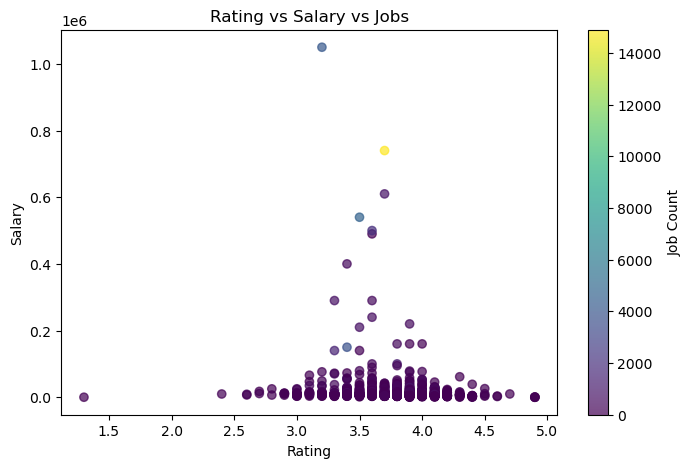

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(df["rating"], df["salary"],c=df["job"], cmap="viridis", alpha=0.7)
plt.colorbar(label="Job Count")
plt.xlabel("Rating")
plt.ylabel("Salary")
plt.title("Rating vs Salary vs Jobs")

plt.show()

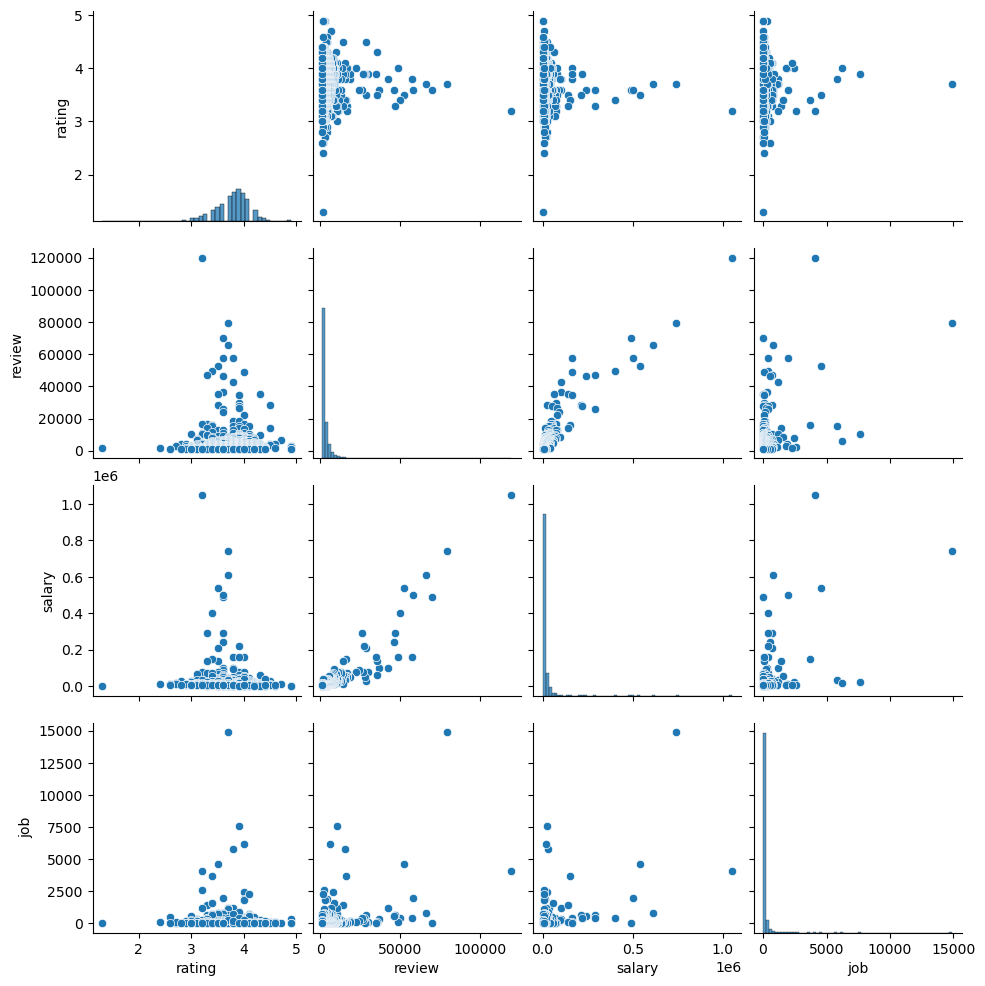

In [23]:
# sns.pairplot(df[["rating","salary","review","job"]])
# plt.show()
sns.pairplot(df, palette="viridis")
plt.show()

------------------------------------------------------------------------------------------------------------------------------------------